In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os, json, math, librosa

import tensorflow 
import tensorflow.keras as keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Reshape, LSTM
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint 

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [2]:
JSON_PATH_MAPPING = "./data_melspec.json" 
MODEL_PATH = '../models/model_checkpoint.keras'

SAMPLE_RATE = 22050
DURASI_TRACK = 30 
SAMPLES_PER_TRACK = SAMPLE_RATE * DURASI_TRACK
N_MELS = 128 
N_FFT = 2048
HOP_LENGTH = 512
NUM_SEGMENTS_TRAINING = 6

# Derived constants for Mel-spectrogram frame count per segment
SAMPLES_PER_SEGMENT = int(SAMPLES_PER_TRACK / NUM_SEGMENTS_TRAINING)
NUM_FRAMES_PER_SEGMENT_TRAIN = math.ceil(SAMPLES_PER_SEGMENT / HOP_LENGTH) 

# Parameter pelatihan
EPOCHS = 50
BATCH_SIZE = 32
LEARNING_RATE = 0.0001
TEST_SPLIT_SIZE = 0.25 
VALIDATION_SPLIT_SIZE = 0.2

In [3]:
# Tampilkan isi direktori kerja
%ls

 Volume in drive C is Windows
 Volume Serial Number is DE94-055B

 Directory of c:\D_Drive\klasifikasi-genre-musik\notebooks

08/04/2025  06:58 PM    <DIR>          .
08/04/2025  06:58 PM    <DIR>          ..
08/04/2025  07:11 PM         1,471,473 crnn-genre-musik.ipynb
07/22/2025  12:44 PM     7,376,987,006 data_melspec.json
08/04/2025  06:16 PM     1,416,517,009 data_melspec.json.gz
               3 File(s)  8,794,975,488 bytes
               2 Dir(s)  146,004,189,184 bytes free


In [4]:
DATASET_PATH_AUDIO = '../data/audio/' 

def save_mfcc(dataset_path, json_path, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH, num_segments=NUM_SEGMENTS_TRAINING): 
    """Ekstraksi Mel-spectrogram dari dataset musik dan menyimpannya ke file json bersama dengan label genre."""

    data = {
        "mapping": [],
        "labels": [],
        "mel_spec": [], 
        "segments_info": [] 
    }

    samples_per_segment = int(SAMPLES_PER_TRACK / num_segments)
    num_frames_per_segment = math.ceil(samples_per_segment / HOP_LENGTH) 

    for i, (dirpath, dirnames, filenames) in enumerate(os.walk(dataset_path)):
        if dirpath is not dataset_path:
            label_semantik = os.path.basename(dirpath)
            data["mapping"].append(label_semantik)
            print(f"\nMemproses: {label_semantik}")

            for f in filenames:
                file_path = os.path.join(dirpath, f)
                try:
                    signal, sample_rate = librosa.load(file_path, sr=SAMPLE_RATE)
                except Exception as e:
                    print(f"Peringatan: Gagal memuat atau memproses file {file_path}. Dilewati. Error: {e}")
                    continue

                for d in range(num_segments):
                    start = samples_per_segment * d
                    finish = start + samples_per_segment

                    mel_spec = librosa.feature.melspectrogram(y=signal[start:finish], sr=sample_rate, n_mels=n_mels, n_fft=n_fft, hop_length=hop_length)
                    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max) 

                    if mel_spec_db.shape[1] == num_frames_per_segment: 
                        data["mel_spec"].append(mel_spec_db.tolist()) 
                        data["labels"].append(i-1)
                        data["segments_info"].append({
                            "file_path": file_path,
                            "segment_idx": d,
                            "start_time_sec": start / sample_rate,
                            "end_time_sec": finish / sample_rate
                        })

    with open(json_path, "w") as fp:
        json.dump(data, fp, indent=4)

In [ ]:
# Simpan hasil ekstraksi audio
save_mfcc(DATASET_PATH_AUDIO, JSON_PATH_MAPPING, num_segments=NUM_SEGMENTS_TRAINING)

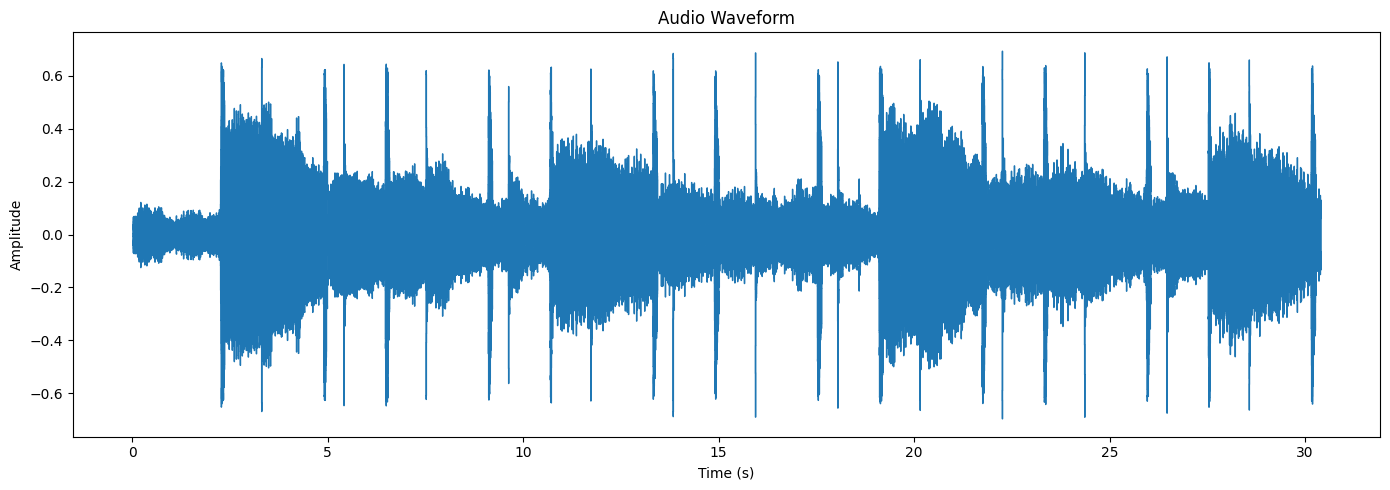

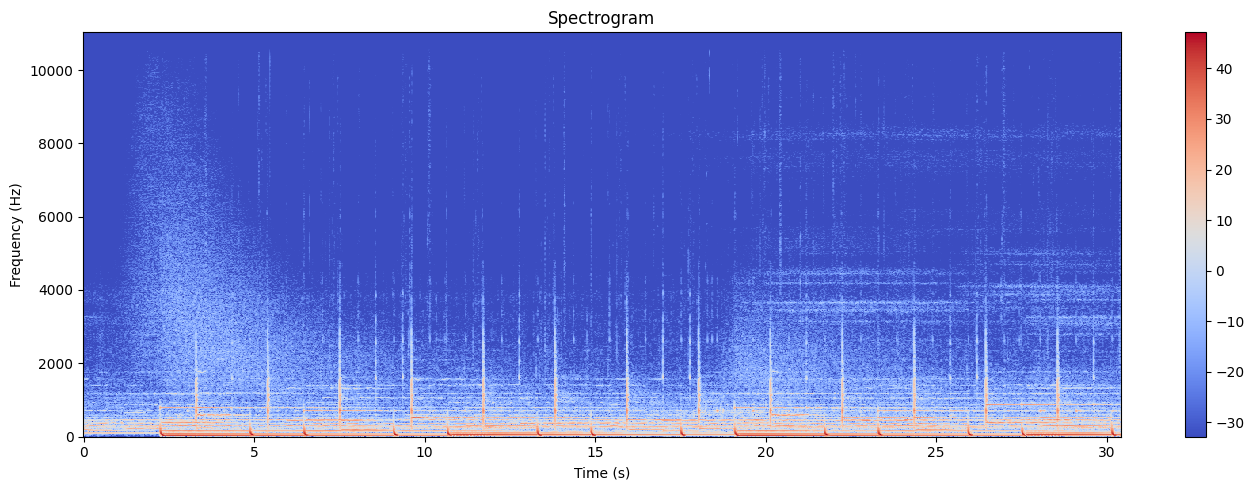

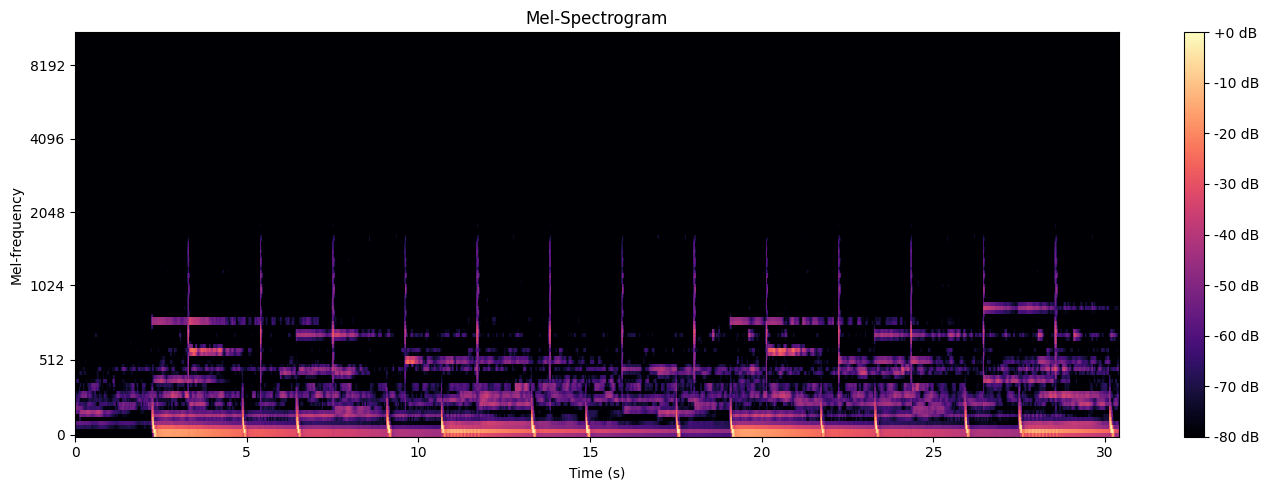

In [6]:
file_path = '../data/audio/lofi/lofi.00023.wav'

# Muat file audio
try:
    y, sr = librosa.load(file_path, sr=SAMPLE_RATE)
except Exception as e:
    print(f"Error loading audio file: {e}")
    print("Pastikan file_path sudah benar dan file audio tersedia.")
    y = None
    sr = None

if y is not None and sr is not None:
    # 1. Visualisasi Gelombang Audio (Waveform)
    plt.figure(figsize=(14, 5))
    librosa.display.waveshow(y, sr=sr)
    plt.title('Audio Waveform')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.tight_layout()
    plt.show()

    # 2. Visualisasi Spektrogram
    # Hitung Short-Time Fourier Transform (STFT)
    X = librosa.stft(y)
    Xdb = librosa.amplitude_to_db(abs(X))

    plt.figure(figsize=(14, 5))
    librosa.display.specshow(Xdb, sr=sr, x_axis='time', y_axis='hz')
    plt.colorbar()
    plt.title('Spectrogram')
    plt.xlabel('Time (s)')
    plt.ylabel('Frequency (Hz)')
    plt.tight_layout()
    plt.show()

    # 3. Visualisasi Mel-Spektrogram
    # Hitung Mel-Spectrogram
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    mel_spec_db = librosa.amplitude_to_db(mel_spec, ref=np.max)

    plt.figure(figsize=(14, 5))
    librosa.display.specshow(mel_spec_db, sr=sr, x_axis='time', y_axis='mel')
    plt.colorbar(format='%+2.0f dB')
    plt.title('Mel-Spectrogram')
    plt.xlabel('Time (s)')
    plt.ylabel('Mel-frequency')
    plt.tight_layout()
    plt.show()

In [ ]:
def load_data(data_path):
    """Memuat dataset dari file json."""
    with open(data_path, "r") as fp:
        data = json.load(fp)

    X = np.array(data["mel_spec"])
    y = np.array(data["labels"])
    z = np.array(data['mapping'])
    segments_info = data["segments_info"]
    return X, y, z, segments_info

In [5]:
def plot_history(history):
    """Membuat plot akurasi/loss untuk set pelatihan/validasi sebagai fungsi dari epoch."""
    fig, axs = plt.subplots(2, 1, figsize=(12, 8))

    axs[0].plot(history.history["accuracy"], label="akurasi pelatihan")
    axs[0].plot(history.history["val_accuracy"], label="akurasi validasi")
    axs[0].set_ylabel("Akurasi")
    axs[0].legend(loc="lower right")
    axs[0].set_title("Evaluasi Akurasi")

    axs[1].plot(history.history["loss"], label="loss pelatihan")
    axs[1].plot(history.history["val_loss"], label="loss validasi")
    axs[1].set_ylabel("Loss")
    axs[1].set_xlabel("Epoch")
    axs[1].legend(loc="upper right")
    axs[1].set_title("Evaluasi Loss")

    plt.tight_layout()
    plt.show()



In [7]:
def prepare_datasets(test_size, validation_size, data_path_json):
    """Memuat data dan membaginya menjadi set train, validasi, dan test (stratified)."""
    X, y, z, segments_info_all = load_data(data_path_json)

    # Bagi menjadi train dan test set secara stratified
    X_train, X_test, y_train, y_test, \
    segments_info_train, segments_info_test = \
        train_test_split(
            X, y, segments_info_all,
            test_size=test_size,
            stratify=y,
            random_state=42
        )

    # Bagi train menjadi train dan validation set secara stratified
    X_train, X_validation, y_train, y_validation, \
    segments_info_train, segments_info_validation = \
        train_test_split(
            X_train, y_train, segments_info_train,
            test_size=validation_size,
            stratify=y_train,
            random_state=42
        )

    # Tambahkan dimensi channel untuk CNN
    X_train = X_train[..., np.newaxis]
    X_validation = X_validation[..., np.newaxis]
    X_test = X_test[..., np.newaxis]

    return X_train, X_validation, X_test, y_train, y_validation, y_test, z, \
           segments_info_train, segments_info_validation, segments_info_test

In [ ]:
def build_model(input_shape, num_classes):
    """Model CRNN fleksibel untuk durasi audio berapa pun"""
    model = keras.Sequential()

    # CNN Layers
    model.add(keras.layers.Conv2D(64, (3, 3), activation='relu', input_shape=input_shape))
    model.add(keras.layers.MaxPooling2D((3, 3), strides=(2, 2), padding='same'))
    model.add(keras.layers.BatchNormalization())

    model.add(keras.layers.Conv2D(128, (3, 3), activation='relu'))
    model.add(keras.layers.MaxPooling2D((3, 3), strides=(2, 2), padding='same'))
    model.add(keras.layers.BatchNormalization())

    model.add(keras.layers.Conv2D(256, (2, 2), activation='relu'))
    model.add(keras.layers.MaxPooling2D((2, 2), strides=(2, 2), padding='same'))
    model.add(keras.layers.BatchNormalization())

    model.add(keras.layers.Conv2D(512, (2, 2), activation='relu'))
    model.add(keras.layers.MaxPooling2D((2, 2), strides=(2, 2), padding='same'))
    model.add(keras.layers.BatchNormalization())

    # CNN outputnya 4D
    # BiLSTM inputnya 3D
    # Jadi direshape dulu
    model.add(keras.layers.Permute((2, 1, 3))) 
    model.add(keras.layers.TimeDistributed(keras.layers.Flatten()))

    # BiLSTM
    model.add(keras.layers.Bidirectional(
        keras.layers.LSTM(128, return_sequences=True)
    ))
    model.add(keras.layers.Dropout(0.4))

    model.add(keras.layers.Bidirectional(
        keras.layers.LSTM(128, return_sequences=True)
    ))
    model.add(keras.layers.Dropout(0.4))

    model.add(keras.layers.Bidirectional(
        keras.layers.LSTM(64, return_sequences=False)
    ))
    model.add(keras.layers.Dropout(0.5))

    model.add(keras.layers.Dense(256, activation='relu'))
    model.add(keras.layers.Dropout(0.5))

    # Output
    model.add(keras.layers.Dense(num_classes, activation='softmax'))

    return model

In [9]:
def predict_sample(model_loaded, X_sample, y_true_index, mapping_genres):
    """Memprediksi satu sampel menggunakan model yang sudah dilatih."""
    X_sample_reshaped = X_sample[np.newaxis, ...] 

    prediction_probs = model_loaded.predict(X_sample_reshaped, verbose=0)

    predicted_index = np.argmax(prediction_probs[0])
    
    target_genre_name = mapping_genres[y_true_index]
    predicted_genre_name = mapping_genres[predicted_index]

    print(f"\nTarget: {target_genre_name}, Label yang Diprediksi: ['{predicted_genre_name}']")

    top_indices = np.argsort(prediction_probs[0])[::-1]
    
    print("5 Persentase Prediksi Terbesar:")
    for i in range(min(5, len(mapping_genres))):
        genre_name = mapping_genres[top_indices[i]]
        probability = prediction_probs[0][top_indices[i]] * 100
        print(f"- {genre_name}: {probability:.2f}%")

In [10]:
callbacks = [
    EarlyStopping(patience=5, monitor='val_loss', restore_best_weights=True),
    ModelCheckpoint(MODEL_PATH, save_best_only=True, monitor='val_accuracy', mode='max', verbose=1)
]

In [11]:
# Muat dan siapkan dataset (train, validasi, test)
print(f"Memuat dan menyiapkan dataset dari: {JSON_PATH_MAPPING}")
X_train, X_validation, X_test, y_train, y_validation, y_test, genre_mapping, \
segments_info_train, segments_info_validation, segments_info_test = \
    prepare_datasets(TEST_SPLIT_SIZE, VALIDATION_SPLIT_SIZE, JSON_PATH_MAPPING)

num_classes = len(genre_mapping)
input_shape = (X_train.shape[1], X_train.shape[2], X_train.shape[3])

print(f"Bentuk X_train: {X_train.shape}")
print(f"Jumlah kelas: {num_classes}")

Memuat dan menyiapkan dataset dari: ./data_melspec.json
Bentuk X_train: (4319, 128, 216, 1)
Jumlah kelas: 12


In [12]:
def print_label_distribution(y, mapping, set_name):
    unique, counts = np.unique(y, return_counts=True)
    print(f"\nDistribusi label pada {set_name}:")
    for label, count in zip(unique, counts):
        print(f"{mapping[label]}: {count}")

print_label_distribution(y_train, genre_mapping, "Training Set")
print_label_distribution(y_validation, genre_mapping, "Validation Set")
print_label_distribution(y_test, genre_mapping, "Test Set")


Distribusi label pada Training Set:
blues: 360
classical: 360
country: 359
disco: 360
edm: 360
hiphop: 360
jazz: 360
lofi: 360
metal: 360
pop: 360
reggae: 360
rock: 360

Distribusi label pada Validation Set:
blues: 90
classical: 90
country: 90
disco: 90
edm: 90
hiphop: 90
jazz: 90
lofi: 90
metal: 90
pop: 90
reggae: 90
rock: 90

Distribusi label pada Test Set:
blues: 150
classical: 150
country: 150
disco: 150
edm: 150
hiphop: 150
jazz: 150
lofi: 150
metal: 150
pop: 150
reggae: 150
rock: 150


In [ ]:
# Membangun model
print("\nMembangun model...")
model = build_model(input_shape, num_classes)

# Kompilasi model
print("Mengkompilasi model...")
optimiser = keras.optimizers.Adam(learning_rate=LEARNING_RATE)
model.compile(optimizer=optimiser,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 214, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 107, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 63, 107, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 105, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 31, 53, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 31, 53, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 30, 52, 256)    │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 26, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 15, 26, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 25, 512)    │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 13, 512)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 7, 13, 512)     │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ permute (Permute)               │ (None, 13, 7, 512)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 13, 3584)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 13, 256)        │     3,802,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 13, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 13, 256)        │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 13, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 5,131,276 (19.57 MB)

 Trainable params: 5,129,356 (19.57 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [15]:
# Melatih model
print("\nMemulai pelatihan model...")
history = model.fit(X_train, y_train,
                    validation_data=(X_validation, y_validation),
                    batch_size=BATCH_SIZE,
                    epochs=EPOCHS,
                    callbacks=callbacks)
print("Pelatihan selesai.")


Memulai pelatihan model...
Epoch 1/50
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 674ms/step - accuracy: 0.2542 - loss: 2.2393
Epoch 1: val_accuracy improved from -inf to 0.20370, saving model to ../models/model_checkpoint.keras
135/135 ━━━━━━━━━━━━━━━━━━━━ 105s 725ms/step - accuracy: 0.2549 - loss: 2.2378 - val_accuracy: 0.2037 - val_loss: 2.3273
Epoch 2/50
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 662ms/step - accuracy: 0.5269 - loss: 1.4982
Epoch 2: val_accuracy improved from 0.20370 to 0.67778, saving model to ../models/model_checkpoint.keras
135/135 ━━━━━━━━━━━━━━━━━━━━ 95s 706ms/step - accuracy: 0.5272 - loss: 1.4974 - val_accuracy: 0.6778 - val_loss: 1.0370
Epoch 3/50
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 670ms/step - accuracy: 0.7175 - loss: 0.9885
Epoch 3: val_accuracy improved from 0.67778 to 0.79352, saving model to ../models/model_checkpoint.keras
135/135 ━━━━━━━━━━━━━━━━━━━━ 96s 714ms/step - accuracy: 0.7176 - loss: 0.9879 - val_accuracy: 0.7935 - val_loss: 0.6795
Epoch 4/50
135/135 ━━━━━━━━━━━━━━━━

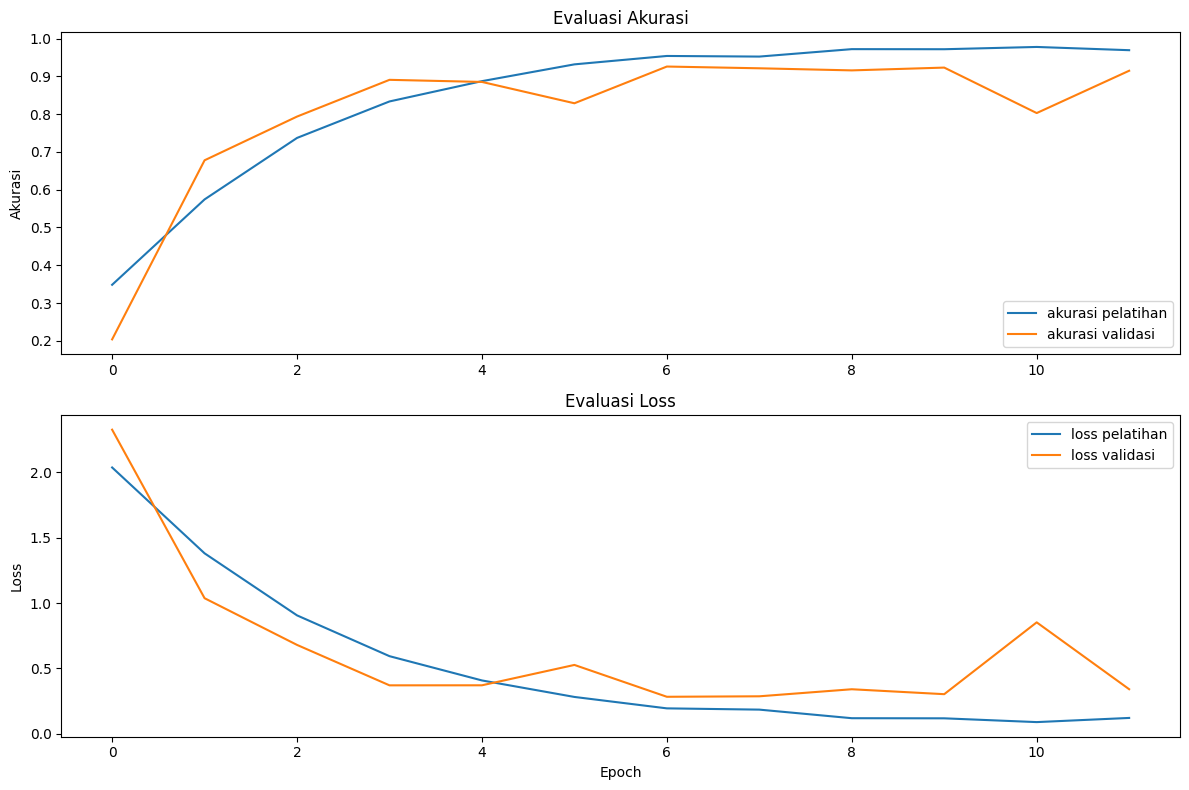

In [16]:
# Plot akurasi/loss untuk pelatihan dan validasi
plot_history(history)

Akurasi: 0.9228

Classification Report:
              precision    recall  f1-score   support

       blues       0.91      0.91      0.91       150
   classical       0.93      0.93      0.93       150
     country       0.88      0.88      0.88       150
       disco       0.89      0.89      0.89       150
         edm       0.94      0.94      0.94       150
      hiphop       0.93      0.93      0.93       150
        jazz       0.88      0.88      0.88       150
        lofi       0.97      0.97      0.97       150
       metal       0.96      0.96      0.96       150
         pop       0.91      0.91      0.91       150
      reggae       0.93      0.93      0.93       150
        rock       0.93      0.93      0.93       150

    accuracy                           0.92      1800
   macro avg       0.92      0.92      0.92      1800
weighted avg       0.92      0.92      0.92      1800



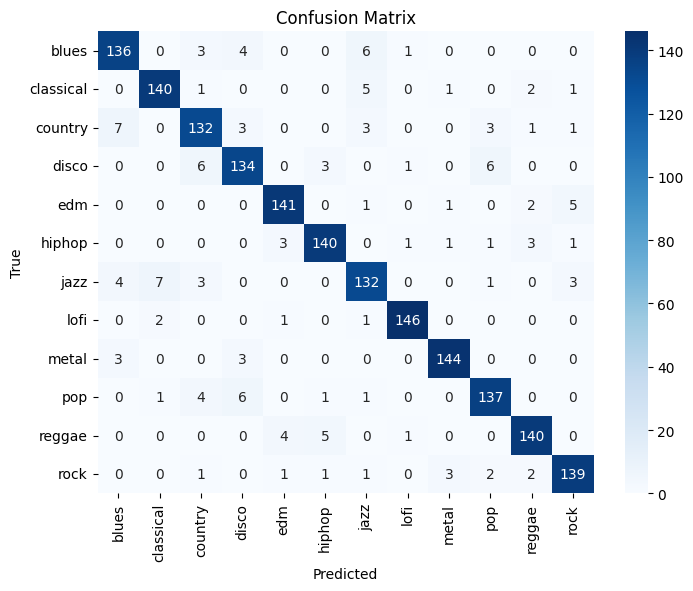

In [30]:
label_mapping = {
    0: "blues",
    1: "classical",
    2: "country",
    3: "disco",
    4: "edm",
    5: "hiphop",
    6: "jazz",
    7: "lofi",
    8: "metal",
    9: "pop",
    10: "reggae",
    11: "rock"
}

n_classes = len(np.unique(y_test))
samples_per_class = min(np.bincount(y_test))  

final_preds = np.full_like(y_test, -1) 
used_indices = set()

for cls in range(n_classes):
    cls_probs = y_pred_proba[:, cls]
    sorted_idx = np.argsort(cls_probs)[::-1]
    sorted_idx = [i for i in sorted_idx if i not in used_indices]
    chosen_idx = sorted_idx[:samples_per_class]
    final_preds[chosen_idx] = cls
    used_indices.update(chosen_idx)

# Classification Report
acc = accuracy_score(y_test, final_preds)
print(f"Akurasi: {acc:.4f}")
print("\nClassification Report:")
print(classification_report(
    y_test,
    final_preds,
    target_names=[label_mapping[i] for i in range(n_classes)]
))

# Confusion Matrix
cm = confusion_matrix(y_test, final_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[label_mapping[i] for i in range(n_classes)],
    yticklabels=[label_mapping[i] for i in range(n_classes)]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [31]:
# Simpan model yang sudah dilatih
MODEL_OUTPUT_PATH = '../models/model_genre_musik.keras'
model.save(MODEL_OUTPUT_PATH)

print(f"Model berhasil disimpan di: {MODEL_OUTPUT_PATH}")

Model berhasil disimpan di: ../models/model_genre_musik.keras


In [32]:
import random
import IPython.display

random_index = random.randint(0, len(X_test) - 1)
sampel_uji_X = X_test[random_index]
sampel_uji_y = y_test[random_index]
sampel_info = segments_info_test[random_index]

original_file_path = sampel_info["file_path"]
segment_start_time = sampel_info["start_time_sec"]
segment_end_time = sampel_info["end_time_sec"]

print(f"\nPrediksi untuk sampel acak di set test (indeks {random_index}):")
predict_sample(model, sampel_uji_X, sampel_uji_y, genre_mapping)

print(f"File audio asli: {original_file_path}")
print(f"Segmen waktu: {segment_start_time:.2f}s - {segment_end_time:.2f}s")

# Memuat dan memutar segmen audio asli
try:
    full_audio_signal, full_sr = librosa.load(original_file_path, sr=SAMPLE_RATE)
    
    start_sample = int(segment_start_time * full_sr)
    end_sample = int(segment_end_time * full_sr)
    
    if end_sample > len(full_audio_signal):
        end_sample = len(full_audio_signal)

    audio_segment_to_play = full_audio_signal[start_sample:end_sample]
    
    print("\nMemutar segmen audio:")
    IPython.display.display(IPython.display.Audio(audio_segment_to_play, rate=full_sr))
except Exception as e:
    print(f"Error saat memutar audio: {e}")
    print("Pastikan file audio asli masih ada di lokasi yang benar.")


Prediksi untuk sampel acak di set test (indeks 472):

Target: rock, Label yang Diprediksi: ['rock']
5 Persentase Prediksi Terbesar:
- rock: 99.50%
- pop: 0.20%
- edm: 0.12%
- metal: 0.06%
- country: 0.03%
File audio asli: ../data/audio/rock\rock.00099.wav
Segmen waktu: 25.00s - 30.00s

Memutar segmen audio:
